In [1]:
from pathlib import Path

retrieval_dir = Path("../src/radar_lwc/retrieval").resolve()
print(retrieval_dir)
print(list(retrieval_dir.glob("*.py")))

C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval
[WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/average_ze_time.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/ddwr_dh.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/dielectric.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/gas_attenuation.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/kappa_liquid.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/zhu.py')]


In [2]:
# %% Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(str(Path("../src").resolve()))

# Preprocessing
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity

# Retrieval
from radar_lwc.retrieval.average_ze_time import avg_ze_time
from radar_lwc.retrieval.ddwr_dh import compute_ddwr_dh
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu

In [3]:
in_path = Path("../data/processed/retrieval_input_2km.nc")
ds_retrieval = xr.open_dataset(in_path)
print(ds_retrieval)

<xarray.Dataset> Size: 27MB
Dimensions:        (Time: 10441, range: 74)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    TAlt           (range) float32 296B ...
    HAlt           (range) float32 296B ...
Data variables:
    Ze_W           (Time, range) float32 3MB ...
    Ze_Ka          (Time, range) float32 3MB ...
    T_cloud        (Time, range) float32 3MB ...
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 3MB ...
    cloud_mask     (Time, range) bool 773kB ...
    combined_mask  (Time, range) bool 773kB ...
    common_mask    (Time, range) bool 773kB ...
    alpha_W        (Time, range) float32 3MB ...
    alpha_Ka       (Time, range) float32 3MB ...
    kappa_W        (Time, range) float32 3MB ...
    kappa_Ka       (Time, range) float32 3MB ...
Attributes:
    description:  Prepared inputs for Zhu et al. (2019) LWC ret

In [4]:
lwc, derivative = retrieve_lwc_zhu(
    dwr=ds_retrieval["DWR"],
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=ds_retrieval["cloud_mask"],
    N_default=9,
    min_cloud_gates=3,
)

dDWR_dH

Without Averaging

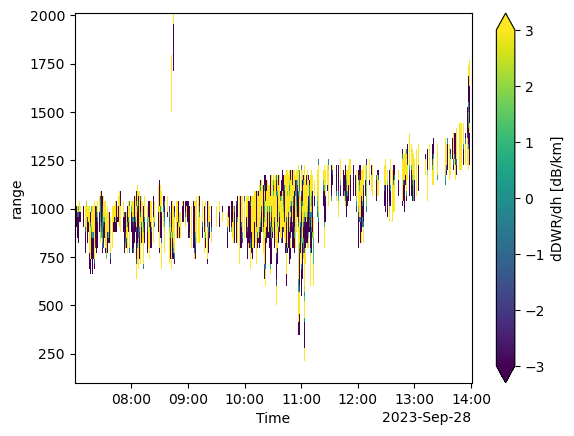

In [5]:
derivative.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=-3,
    vmax=3,
    cbar_kwargs={"label": "dDWR/dh [dB/km]"}
)

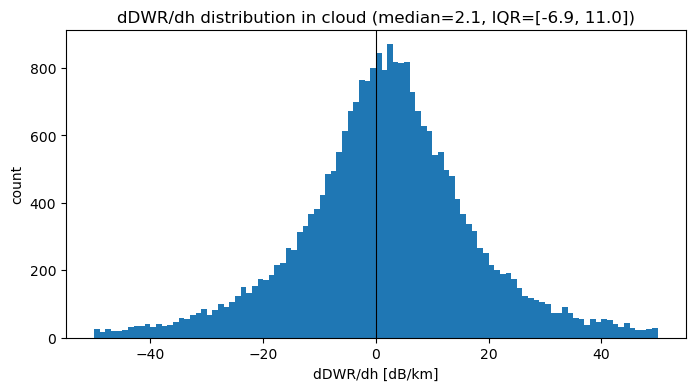

Fraction of gates with dDWR/dh < 0:   43.50%
Fraction with |dDWR/dh| > 30 dB/km:   9.98%


In [6]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = derivative.where(ds_retrieval["combined_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")

In [7]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = ds_retrieval["DWR"].where(ds_retrieval["combined_mask"]).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise;     Better Explanation in OneNote Programmieren/dual_freq_radar/Notebooks 03;  If DWR is seen as constant between neighbours, the difference between the measurements Y and X is just the difference between the noise of the two gates eps_1 and eps_2. 
# Var(Y-X) = Var(eps_1 - eps_2) =[Covariance between noise is 0]--> Var(eps_1) + Var(eps_2) = 2 * Var(eps) ;   So, std(Y-X) = sqrt(2) * std(eps) ;   So, std(eps) = std(Y-X)/sqrt(2)   std (sigma) is standard deviation and Var (sigma^2) is Variance
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(ds_retrieval['DWR'].where(ds_retrieval['cloud_mask']).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.2:.2f} dB")    # Comparison Noise and Signal across  Window


Estimated per-gate DWR noise: 0.69 dB
Median in-cloud DWR:          1.80 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


--> ZU HOCH

<xarray.DataArray 'LWC' (Time: 10441, range: 74)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(10441, 74))
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt     (range) float32 296B ...
    HAlt     (range) float32 296B ...
Attributes:
    units:                      g m-3
    long_name:                  Liquid Water Content (Zhu et al. 2019 retrieval)
    method:                     Sliding-window quadratic DWR gradient
    window_size_default_gates:  9
    min_cloud_gates:            3


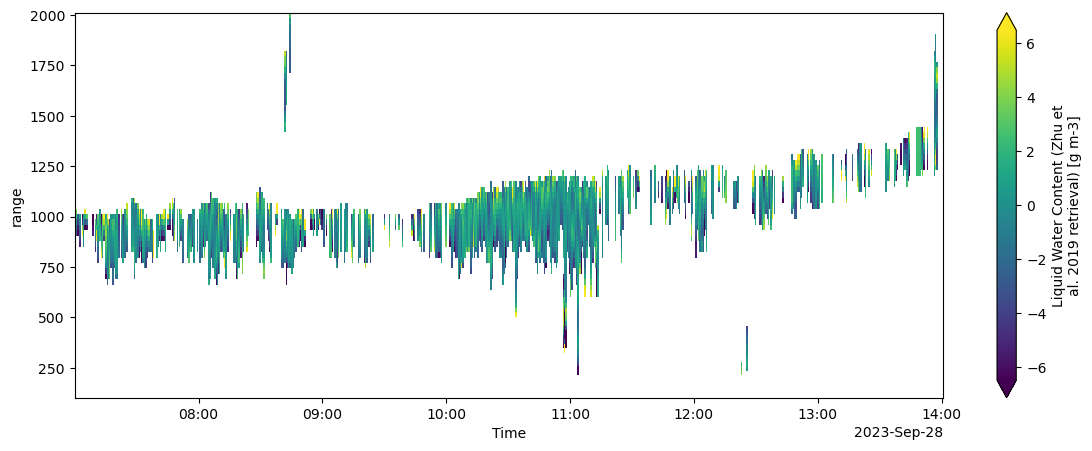

In [8]:
print(lwc)

lwc.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

In [9]:
print(f"Fraction LWC < 0: "
      f"{float((lwc < 0).sum() / lwc.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc.quantile(0.05)):.2f}, "
      f"p50={float(lwc.quantile(0.5)):.2f}, "
      f"p95={float(lwc.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 47.56%
LWC quantiles: p05=-4.22, p50=0.11, p95=4.25 g/m³


================================================================================================================================================================================================

TEMPORAL AVERAGING OVER TIME TO REDUCE PERCENTAGE OF DDWR/DH <0 AND DDWR/DH >30

================================================================================================================================================================================================

================================================================================================================================================================================================

AVERAGING OVER 30s

================================================================================================================================================================================================

In [10]:
ze_ka_avg = avg_ze_time(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)), window_s=30)
ze_w_avg  = avg_ze_time(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)),  window_s=30)

dwr_2km_smoothed = ze_ka_avg - ze_w_avg
dwr_2km_smoothed.name = "DWR"

# Re-run the diagnostic
ddwr_dh_smoothed = compute_ddwr_dh(dwr_2km_smoothed, ds_retrieval["combined_mask"], N_default=9)

vals = ddwr_dh_smoothed.where(ds_retrieval["combined_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
print(f"After 30 s time-averaging:")
print(f"  Fraction dDWR/dh < 0:            {(vals < 0).mean():.2%}")
print(f"  Fraction |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")
print(f"  median dDWR/dh:                  {np.median(vals):.2f} dB/km")

After 30 s time-averaging:
  Fraction dDWR/dh < 0:            28.28%
  Fraction |dDWR/dh| > 30 dB/km:   1.95%
  median dDWR/dh:                  2.27 dB/km


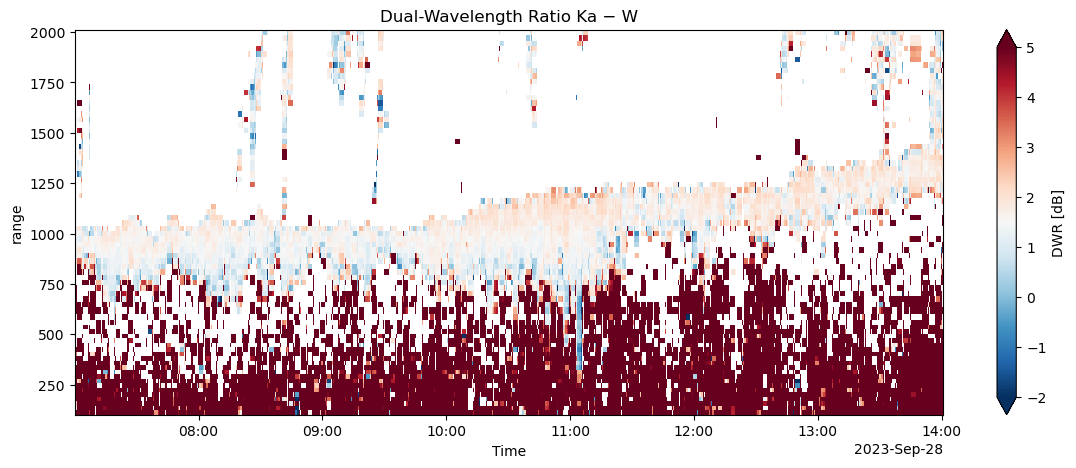

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km_smoothed.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

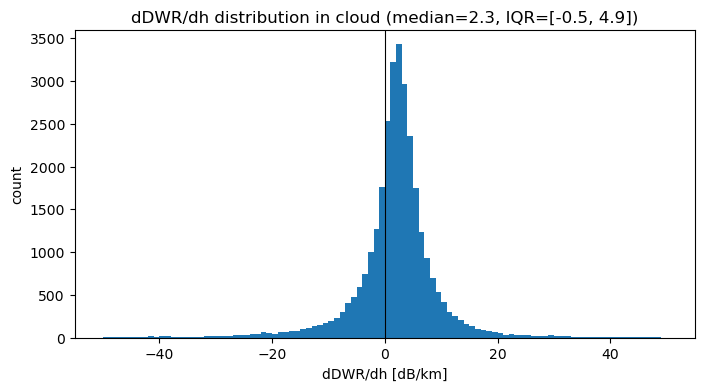

Fraction of gates with dDWR/dh < 0:   28.28%
Fraction with |dDWR/dh| > 30 dB/km:   1.95%


In [12]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = ddwr_dh_smoothed.where(ds_retrieval["combined_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")

LWC 30s Averaging

In [13]:
lwc_2, derivative_2 = retrieve_lwc_zhu(
    dwr=dwr_2km_smoothed,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=ds_retrieval["combined_mask"],
    N_default=9,
    min_cloud_gates=3,
)

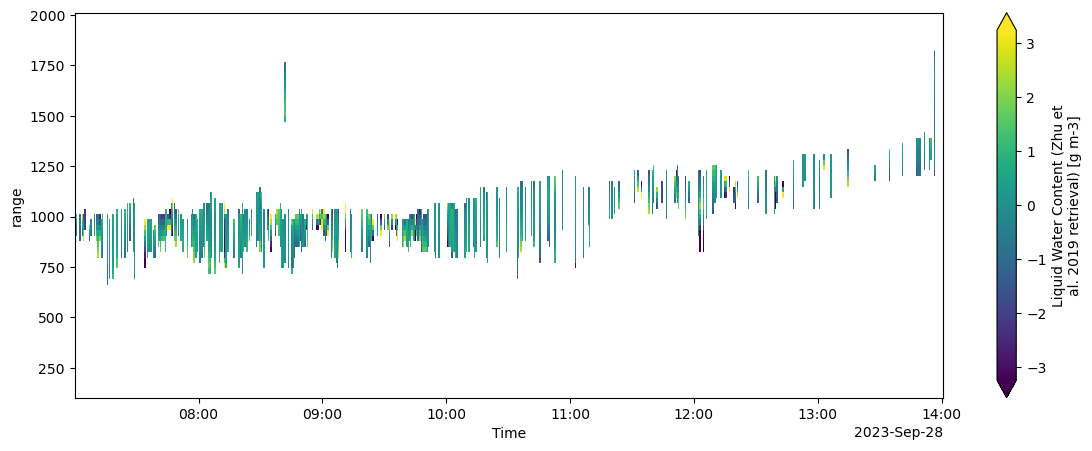

In [14]:
lwc_2.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

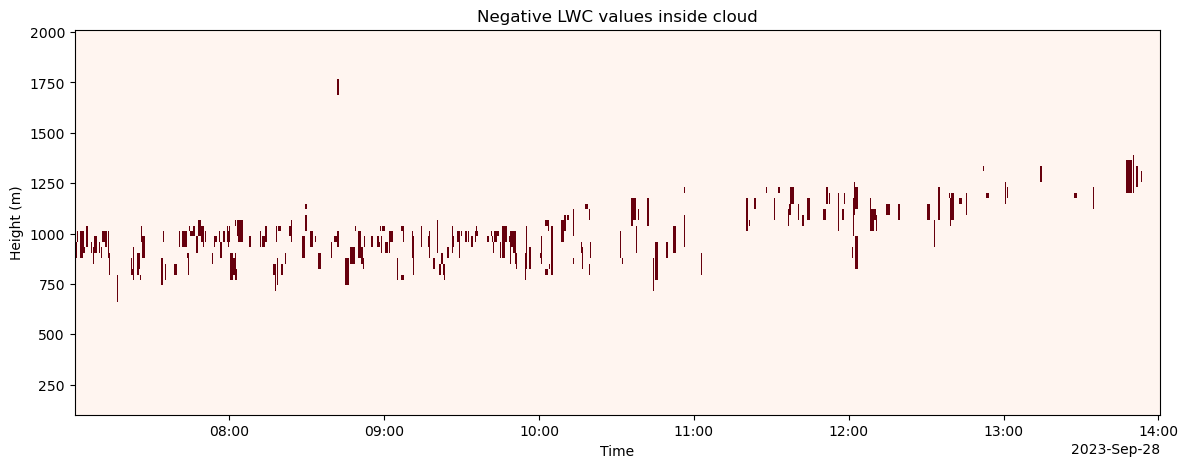

In [15]:
# %% Negative LWC locations

negative_lwc = (lwc_2 < 0) & ds_retrieval["combined_mask"]

plt.figure(figsize=(14, 5))

negative_lwc.astype(int).plot(
    x="Time",
    y="range",
    cmap="Reds",
    add_colorbar=False,
)

plt.title("Negative LWC values inside cloud")
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.show()

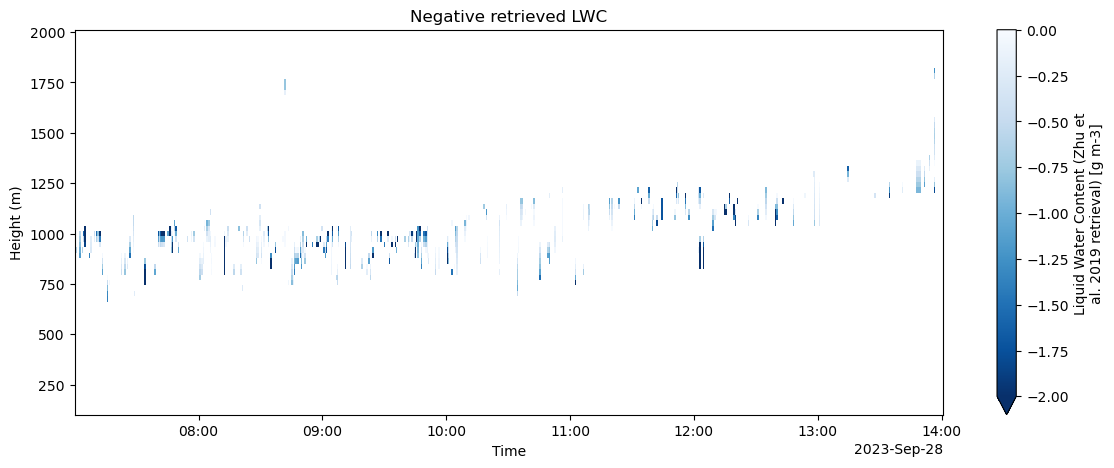

In [16]:
# %% Negative LWC values

lwc_negative = lwc_2.where((lwc_2 < 0) & ds_retrieval["combined_mask"])

plt.figure(figsize=(14, 5))

lwc_negative.plot(
    x="Time",
    y="range",
    cmap="Blues_r",
    vmin=-2,
    vmax=0,
)

plt.title("Negative retrieved LWC")
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.show()

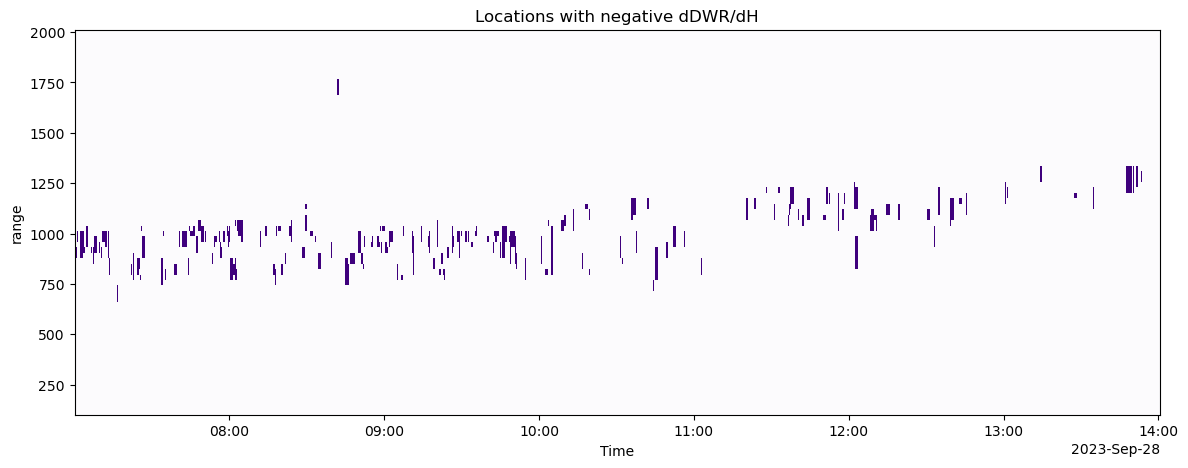

In [17]:
negative_grad = (derivative_2 < 0) & ds_retrieval["combined_mask"]

plt.figure(figsize=(14,5))

negative_grad.astype(int).plot(
    x="Time",
    y="range",
    cmap="Purples",
    add_colorbar=False,
)

plt.title("Locations with negative dDWR/dH")
plt.show()

In [18]:
print(f"Fraction LWC < 0: "
      f"{float((lwc_2 < 0).sum() / lwc_2.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_2.quantile(0.05)):.2f}, "
      f"p50={float(lwc_2.quantile(0.5)):.2f}, "
      f"p95={float(lwc_2.quantile(0.95)):.2f} g/m³")

Fraction LWC < 0: 36.74%
LWC quantiles: p05=-1.72, p50=0.18, p95=1.64 g/m³


In [19]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = dwr_2km_smoothed.where(ds_retrieval["combined_mask"]).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km_smoothed.where(ds_retrieval["combined_mask"]).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.20:.2f} dB")    # Comparison Noise and Signal across  Window

Estimated per-gate DWR noise: 0.34 dB
Median in-cloud DWR:          1.55 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


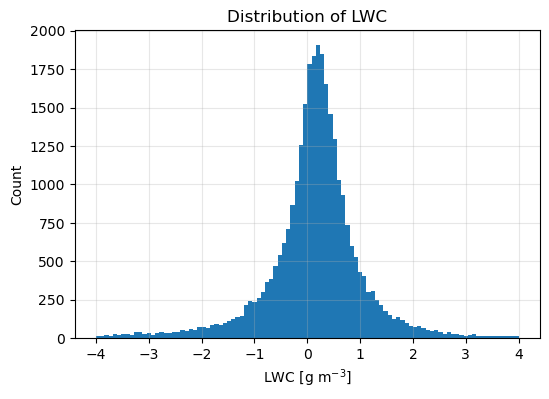

In [20]:
vals = lwc_2.where(ds_retrieval["combined_mask"]).values
vals = vals[np.isfinite(vals)]

plt.figure(figsize=(6,4))
plt.hist(vals, bins=100, range=(-4, 4))
plt.xlabel("LWC [g m$^{-3}$]")
plt.ylabel("Count")
plt.title("Distribution of LWC")
plt.grid(alpha=0.3)
plt.show()

================================================================================================================================================================================================

60s AVERAGING

================================================================================================================================================================================================

In [21]:
ze_ka_avg = avg_ze_time(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)), window_s=60)
ze_w_avg  = avg_ze_time(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)),  window_s=60)

dwr_2km_smoothed_60 = ze_ka_avg - ze_w_avg
dwr_2km_smoothed_60.name = "DWR"

# Re-run the diagnostic
ddwr_dh_smoothed_60 = compute_ddwr_dh(dwr_2km_smoothed_60, ds_retrieval["combined_mask"], N_default=9)

vals = ddwr_dh_smoothed_60.where(ds_retrieval["combined_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
print(f"After 60 s time-averaging:")
print(f"  Fraction dDWR/dh < 0:            {(vals < 0).mean():.2%}")
print(f"  Fraction |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")
print(f"  median dDWR/dh:                  {np.median(vals):.2f} dB/km")

After 60 s time-averaging:
  Fraction dDWR/dh < 0:            26.26%
  Fraction |dDWR/dh| > 30 dB/km:   1.51%
  median dDWR/dh:                  2.36 dB/km


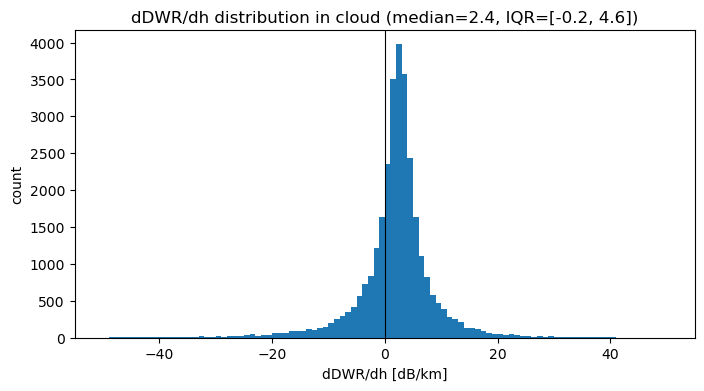

Fraction of gates with dDWR/dh < 0:   26.26%
Fraction with |dDWR/dh| > 30 dB/km:   1.51%


In [22]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = ddwr_dh_smoothed_60.where(ds_retrieval["combined_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")

LWC 60s Averaging

In [23]:
lwc_60, derivative_60 = retrieve_lwc_zhu(
    dwr=dwr_2km_smoothed_60,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=ds_retrieval["combined_mask"],
    N_default=9,
    min_cloud_gates=3,
)

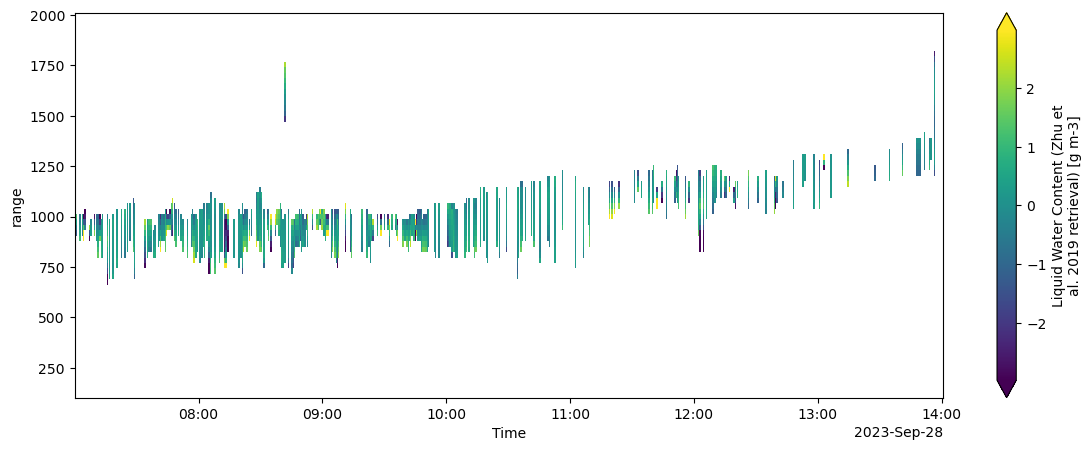

In [24]:
lwc_60.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

In [25]:
print(f"Fraction LWC < 0: "
      f"{float((lwc_60 < 0).sum() / lwc_60.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_60.quantile(0.05)):.2f}, "
      f"p50={float(lwc_60.quantile(0.5)):.2f}, "
      f"p95={float(lwc_60.quantile(0.95)):.2f} g/m³")

Fraction LWC < 0: 34.13%
LWC quantiles: p05=-1.60, p50=0.19, p95=1.57 g/m³


In [26]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = dwr_2km_smoothed_60.where(ds_retrieval["combined_mask"]).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km_smoothed_60.where(ds_retrieval['combined_mask']).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.20:.2f} dB")    # Comparison Noise and Signal across  Window

Estimated per-gate DWR noise: 0.33 dB
Median in-cloud DWR:          1.53 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


================================================================================================================================================================================================

GUARDED ZHU RETRIEVAL: 30s SMOOTHED BUT THE RETRIEVAL FUNCTION IS DIFFERENT

================================================================================================================================================================================================

max_ddwr_dh=50.0,         # dB/km — physical ceiling on |dDWR/dh|

max_window_std=3.0,    # dB    — reject noisy windows


edge_pad=1,            # skip edge gates near cloud base/top

In [27]:
# %% Guarded retrieval — drop-in replacement to compare against retrieve_lwc_zhu
def retrieve_lwc_zhu_guarded(
    dwr, kappa_w, kappa_ka, alpha_w, alpha_ka, combined_mask,
    N_default=9,
    max_ddwr_dh=50.0,      # dB/km — physical ceiling on |dDWR/dh|
    max_window_std=3.0,    # dB    — reject noisy windows
    edge_pad=1,            # skip edge gates near cloud base/top
):
    """
    Zhu-style LWC retrieval with overlap averaging + sanity guards.
    Assumes dims ('Time', 'range'). Returns (LWC g/m³, n_windows per gate).
    """
    h = dwr["range"].values.astype(float)
    D = dwr.values
    Kw, Kka = kappa_w.values, kappa_ka.values
    Aw, Aka = alpha_w.values, alpha_ka.values
    M = combined_mask.values
    nt, nr = D.shape

    lwc_sum = np.zeros_like(D)
    lwc_cnt = np.zeros_like(D)

    for t in range(nt):
        cloud_idx = np.flatnonzero(M[t])
        if cloud_idx.size < 3:
            continue
        i0 = cloud_idx.min() + edge_pad
        i1 = cloud_idx.max() - edge_pad
        if i1 - i0 + 1 < 3:
            continue
        Nt = min(N_default, i1 - i0 + 1)

        for i in range(i0, i1 - Nt + 2):
            sl = slice(i, i + Nt)
            if not M[t, sl].all():
                continue
            dwin = D[t, sl]
            if not np.isfinite(dwin).all():
                continue
            # Guard: window too noisy?
            if dwin.std() > max_window_std:
                continue
            # Fit quadratic
            a, b, _c = np.polyfit(h[sl], dwin, 2)
            grad = (2 * a * h[sl] + b) * 1000.0   # dB/km
            # Guard: unphysical gradient?
            if np.any(np.abs(grad) > max_ddwr_dh):
                continue
            dkappa = Kw[t, sl] - Kka[t, sl]
            dalpha = Aw[t, sl] - Aka[t, sl]
            with np.errstate(divide="ignore", invalid="ignore"):
                lwc_win = (0.5 * grad - dalpha) / dkappa
            lwc_sum[t, sl] += lwc_win
            lwc_cnt[t, sl] += 1

    with np.errstate(invalid="ignore", divide="ignore"):
        lwc = np.where(lwc_cnt > 0, lwc_sum / lwc_cnt, np.nan)

    lwc_da = xr.DataArray(
        lwc, coords=dwr.coords, dims=dwr.dims, name="lwc",
        attrs={"units": "g m-3", "long_name": "LWC (Zhu 2019, guarded)"},
    )
    n_da = xr.DataArray(lwc_cnt, coords=dwr.coords, dims=dwr.dims, name="n_windows")
    return lwc_da, n_da


lwc_guarded, n_windows = retrieve_lwc_zhu_guarded(
    dwr=dwr_2km_smoothed,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    combined_mask=ds_retrieval["combined_mask"],
    N_default=9,
)


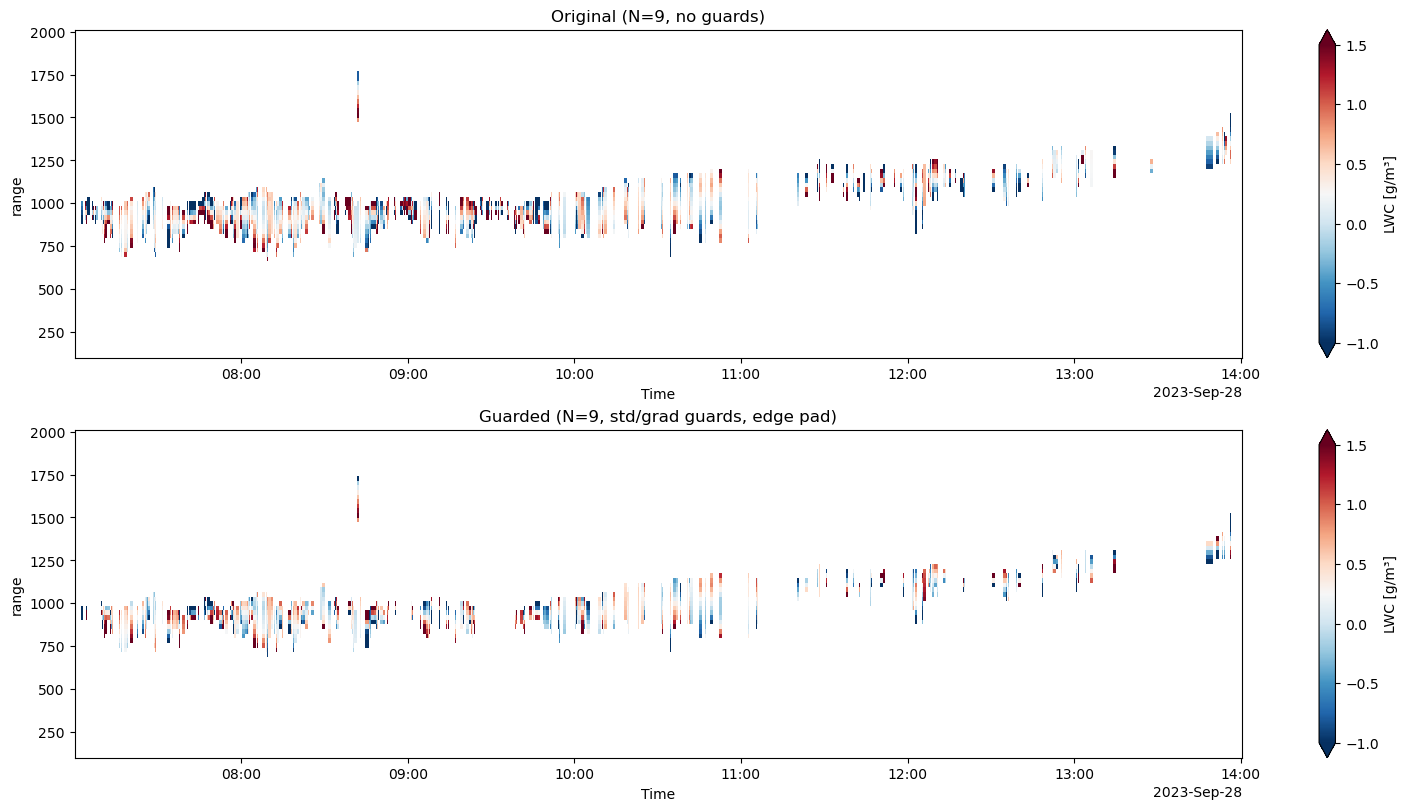

Gates with any retrieval: 21486 (2.8%)
Mean windows per gate:    1.5
Fraction of retrieved LWC < 0: 35.27%
LWC quantiles: p05=-1.35, p50=0.18, p95=1.40


In [28]:
# %% Compare guarded LWC to your original
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
lwc_2.where(ds_retrieval["combined_mask"]).plot(
    x="Time", y="range", ax=axes[0], vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[0].set_title("Original (N=9, no guards)")
lwc_guarded.where(ds_retrieval["combined_mask"]).plot(
    x="Time", y="range", ax=axes[1], vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[1].set_title("Guarded (N=9, std/grad guards, edge pad)")
plt.show()

print(f"Gates with any retrieval: {int((n_windows > 0).sum())} "
      f"({100*float((n_windows>0).mean()):.1f}%)")
print(f"Mean windows per gate:    {float(n_windows.where(n_windows>0).mean()):.1f}")
print(f"Fraction of retrieved LWC < 0: "
      f"{float((lwc_guarded < 0).sum() / lwc_guarded.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_guarded.quantile(0.05)):.2f}, "
      f"p50={float(lwc_guarded.quantile(0.5)):.2f}, "
      f"p95={float(lwc_guarded.quantile(0.95)):.2f}")

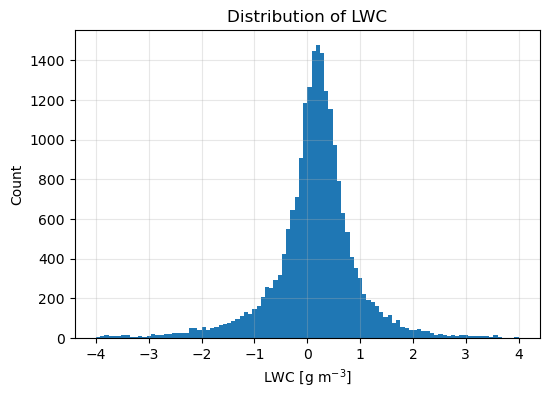

In [29]:
vals = lwc_guarded.where(ds_retrieval["combined_mask"]).values
vals = vals[np.isfinite(vals)]

plt.figure(figsize=(6,4))
plt.hist(vals, bins=100, range=(-4, 4))
plt.xlabel("LWC [g m$^{-3}$]")
plt.ylabel("Count")
plt.title("Distribution of LWC")
plt.grid(alpha=0.3)
plt.show()

================================================================================================================================================================================================

LWP RETRIEVAL

================================================================================================================================================================================================

30s RETRIEVAL

In [30]:
# Height spacing between radar gates (m)  30s AVERAGING
dz = float(ds_retrieval["range"].sel(range=slice(0, 2000)).diff("range").mean())
print(f"Gate spacing = {dz:.1f} m")
# Integrate LWC over height
lwp_2 = (lwc_2 * dz).sum(dim="range") /1000
lwp_guarded = (lwc_guarded * dz).sum(dim="range") /1000


lwp_2.name = "LWP"
lwp_2.attrs["units"] = "kg m^-2"


lwp_guarded.name = "LWP"
lwp_guarded.attrs["units"] = "kg m^-2"

Gate spacing = 25.8 m


30s averaged LWP

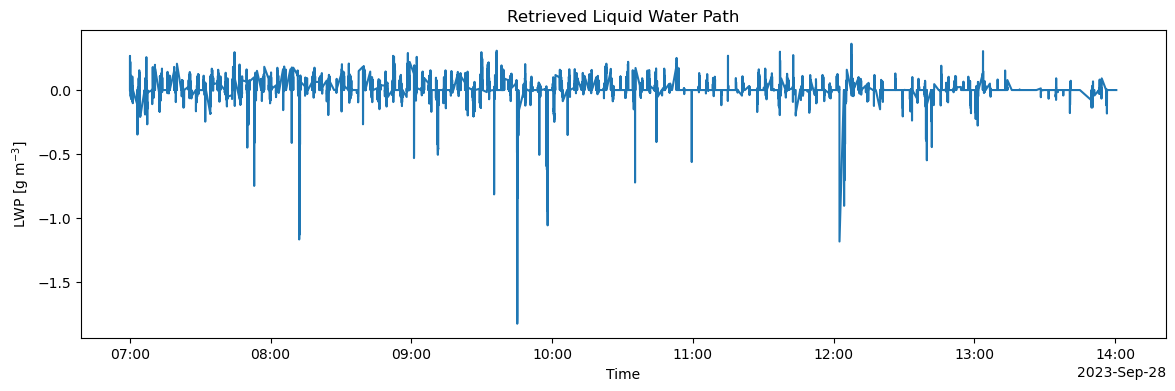

In [31]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp_2.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-3}$]")
ax.set_xlabel("Time")

plt.show()

30s Averaged and Guarded LWP

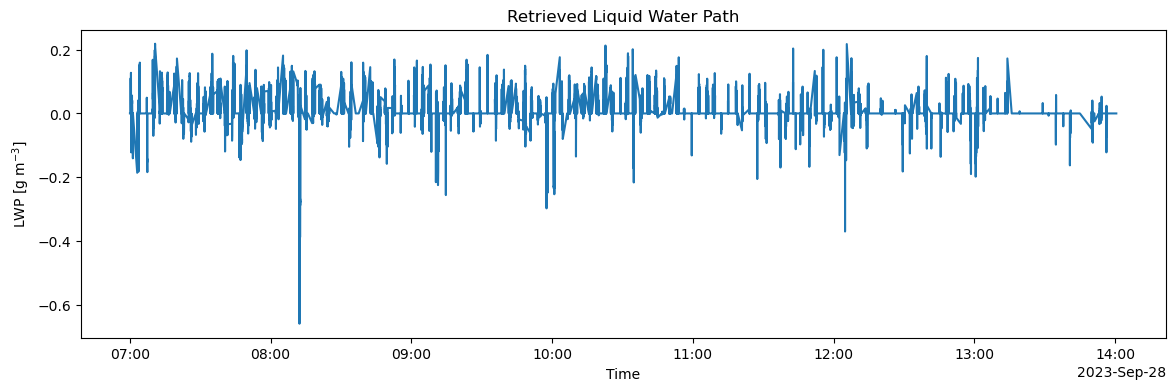

In [32]:
# Guarded LWP
fig, ax = plt.subplots(figsize=(14, 4))

lwp_guarded.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-3}$]")
ax.set_xlabel("Time")

plt.show()

OVER 5 Minutes AVERAGED LWP

In [33]:
# %% Step 3 with what you already have
dz = float(dwr_2km_smoothed["range"].diff("range").mean())
lwp_radar = (lwc_2.where(ds_retrieval["combined_mask"]).fillna(0) * dz).sum(dim="range")
lwp_radar = lwp_radar.where(ds_retrieval["combined_mask"].any(dim="range"))
lwp_radar.attrs["units"] = "g m-2"

# Optionally also time-average LWP over 1–5 minutes to further beat down noise
lwp_radar_5min = lwp_radar.rolling(Time=int(5*60/30), center=True, min_periods=1).mean()

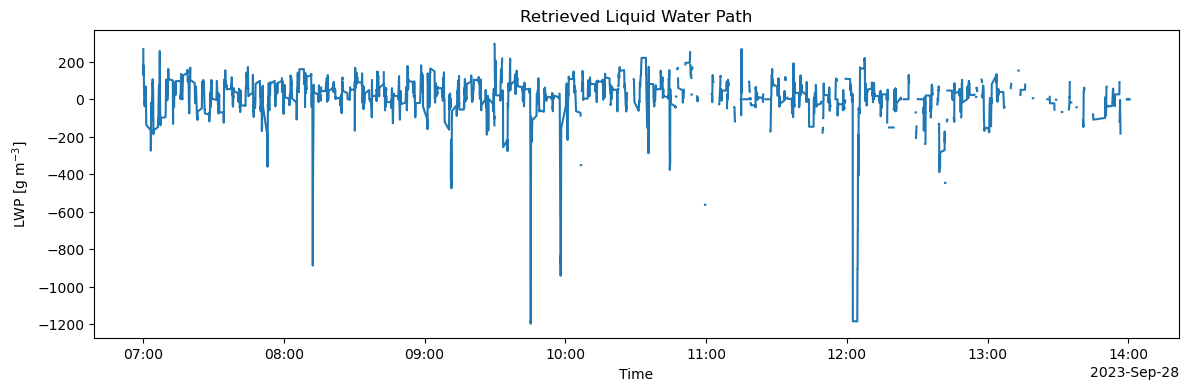

In [34]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp_radar_5min.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-3}$]")
ax.set_xlabel("Time")

plt.show()

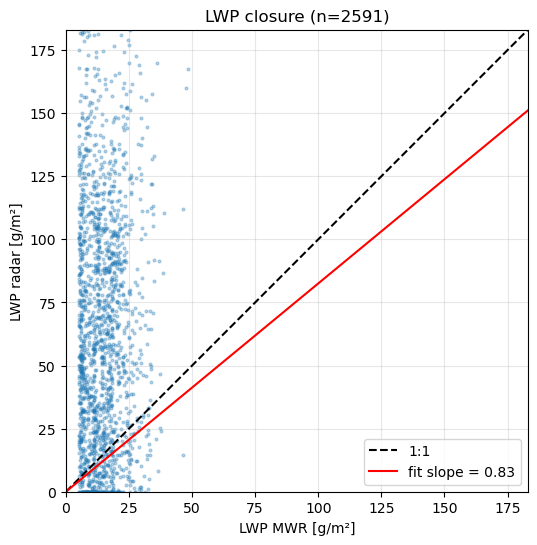

Slope through origin: 0.83   (want ~1.0)
Correlation:          0.02   (want > 0.7)
Bias:  radar - MWR = -0.6 g/m²


In [35]:
# %% LWP closure test
# Integrate guarded LWC to LWP in g/m² (note: NO /1000 — we want g/m², not kg/m²)
dz = float(dwr_2km_smoothed["range"].diff("range").mean())   # ~22.4 m
lwp_radar = (lwc_2.where(ds_retrieval["combined_mask"]).fillna(0) * dz).sum(dim="range")
lwp_radar = lwp_radar.where(ds_retrieval["combined_mask"].any(dim="range"))   # NaN if no cloud
lwp_radar.attrs["units"] = "g m-2"


# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
x = ds_retrieval["LWP"].values
y = lwp_radar.values
good = np.isfinite(x) & np.isfinite(y) & (x > 5)   # ignore near-zero MWR
ax.scatter(x[good], y[good], s=4, alpha=0.3)
lim = max(np.nanpercentile(x[good], 99), np.nanpercentile(y[good], 99))
ax.plot([0, lim], [0, lim], "k--", label="1:1")
slope = np.nansum(x[good] * y[good]) / np.nansum(x[good] ** 2)
ax.plot([0, lim], [0, slope * lim], "r-", label=f"fit slope = {slope:.2f}")
ax.set_xlabel("LWP MWR [g/m²]"); ax.set_ylabel("LWP radar [g/m²]")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"LWP closure (n={good.sum()})")
plt.show()

corr = np.corrcoef(x[good], y[good])[0, 1]
print(f"Slope through origin: {slope:.2f}   (want ~1.0)")
print(f"Correlation:          {corr:.2f}   (want > 0.7)")
print(f"Bias:  radar - MWR = {np.nanmean(y[good] - x[good]):+.1f} g/m²")


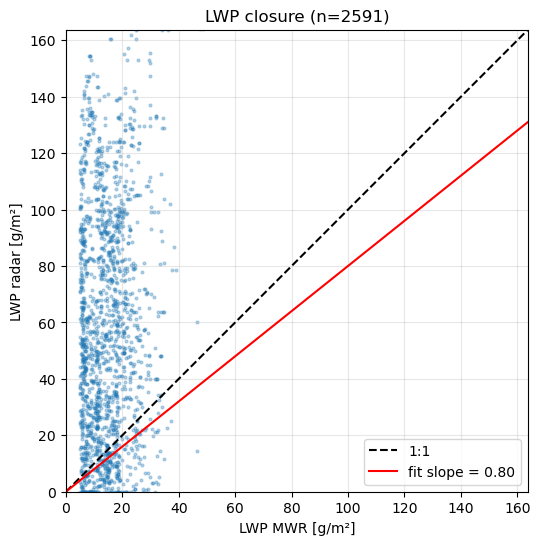

Slope through origin: 0.80   (want ~1.0)
Correlation:          0.02   (want > 0.7)
Bias:  radar - MWR = -1.0 g/m²


In [36]:
# %% LWP closure test
# Integrate guarded LWC to LWP in g/m² (note: NO /1000 — we want g/m², not kg/m²)
dz = float(dwr_2km_smoothed["range"].diff("range").mean())   # ~22.4 m

lwp_radar_5min = lwp_radar_5min.where(ds_retrieval["combined_mask"].any(dim="range"))   # NaN if no cloud
lwp_radar_5min.attrs["units"] = "g m-2"


# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
x = ds_retrieval["LWP"].values
y = lwp_radar_5min.values
good = np.isfinite(x) & np.isfinite(y) & (x > 5)   # ignore near-zero MWR
ax.scatter(x[good], y[good], s=4, alpha=0.3)
lim = max(np.nanpercentile(x[good], 99), np.nanpercentile(y[good], 99))
ax.plot([0, lim], [0, lim], "k--", label="1:1")
slope = np.nansum(x[good] * y[good]) / np.nansum(x[good] ** 2)
ax.plot([0, lim], [0, slope * lim], "r-", label=f"fit slope = {slope:.2f}")
ax.set_xlabel("LWP MWR [g/m²]"); ax.set_ylabel("LWP radar [g/m²]")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"LWP closure (n={good.sum()})")
plt.show()

corr = np.corrcoef(x[good], y[good])[0, 1]
print(f"Slope through origin: {slope:.2f}   (want ~1.0)")
print(f"Correlation:          {corr:.2f}   (want > 0.7)")
print(f"Bias:  radar - MWR = {np.nanmean(y[good] - x[good]):+.1f} g/m²")


In [37]:
# %% A1: How many "cloud" gates per profile?
gates_per_profile = ds_retrieval["combined_mask"].sum(dim="range")
print(f"Gates flagged as cloud per profile:")
print(f"  p05={float(gates_per_profile.quantile(0.05)):.0f}")
print(f"  p50={float(gates_per_profile.quantile(0.50)):.0f}")
print(f"  p95={float(gates_per_profile.quantile(0.95)):.0f}")
print(f"  max possible: {ds_retrieval['combined_mask'].sizes['range']}")


Gates flagged as cloud per profile:
  p05=0
  p50=0
  p95=12
  max possible: 74


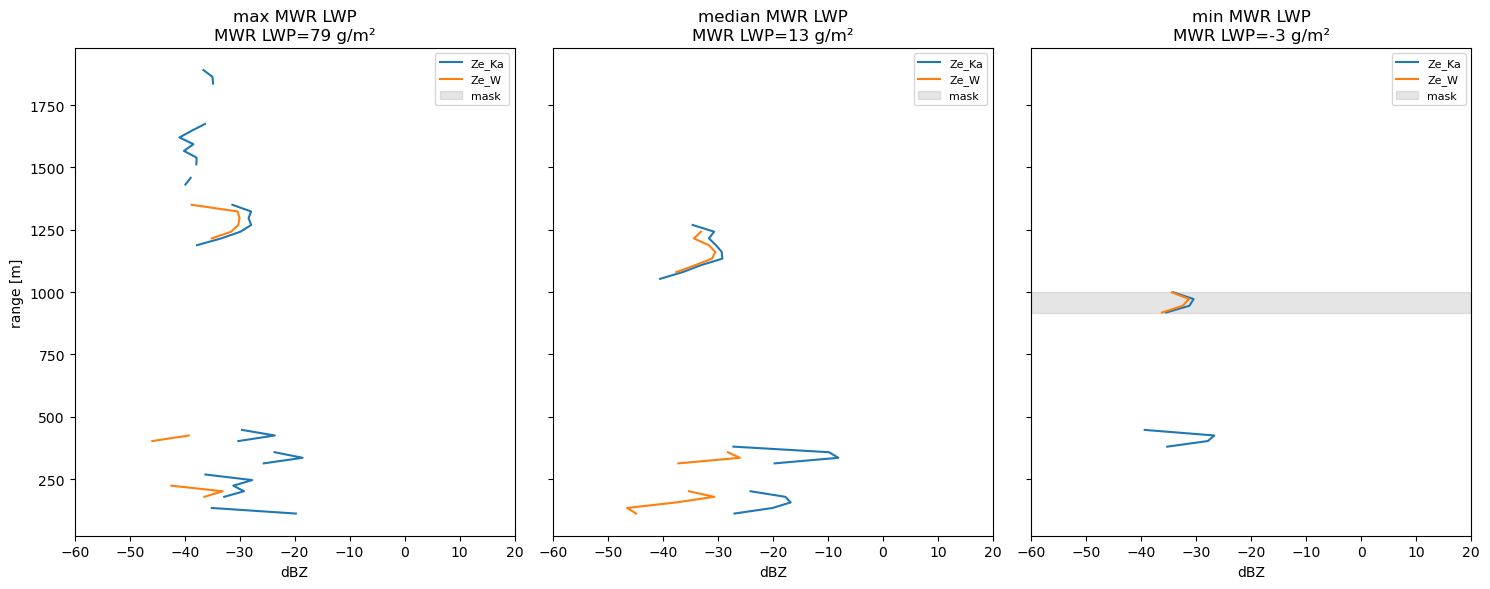

In [38]:
# %% A2: Spot-check three profiles - Ze_Ka, Ze_W, mask, LWC side by side
import matplotlib.pyplot as plt

# Pick 3 times: one from a high-MWR-LWP moment, one low, one middle
lwp_mwr_vals = ds_retrieval["LWP"].values
i_hi  = int(np.nanargmax(lwp_mwr_vals))
i_lo  = int(np.nanargmin(np.abs(lwp_mwr_vals - np.nanmedian(lwp_mwr_vals))))
i_zero = int(np.nanargmin(lwp_mwr_vals))

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, idx, label in zip(axes, [i_hi, i_lo, i_zero],
                          ["max MWR LWP", "median MWR LWP", "min MWR LWP"]):
    h = dwr_2km_smoothed["range"].values
    ax.plot(ds_retrieval["Ze_Ka"].sel(range=slice(0,2000)).isel(Time=idx), h, label="Ze_Ka")
    ax.plot(ds_retrieval["Ze_W"].sel(range=slice(0,2000)).isel(Time=idx),  h, label="Ze_W")
    mask_here = ds_retrieval["combined_mask"].isel(Time=idx)
    ax.fill_betweenx(h, -60, 20, where=mask_here, color="grey", alpha=0.2, label="mask")
    ax.set_xlim(-60, 20); ax.set_xlabel("dBZ")
    ax.set_title(f"{label}\nMWR LWP={lwp_mwr_vals[idx]:.0f} g/m²")
    ax.legend(fontsize=8)
axes[0].set_ylabel("range [m]")
plt.tight_layout(); plt.show()


In [39]:
# %% B1: Tighter threshold
cloud_mask_tight = (
    ds_retrieval["Ze_Ka"].notnull() & ds_retrieval["Ze_W"].notnull()
    & (ds_retrieval["Ze_Ka"] > -35) & (ds_retrieval["Ze_W"] > -35)
).sel(range=slice(0, 2000))

# %% B2: Contiguity - keep only the LARGEST contiguous cloud block per profile
from scipy.ndimage import label

def largest_contiguous_1d(mask_1d):
    """Return mask keeping only the largest contiguous True block."""
    if not mask_1d.any():
        return mask_1d
    lbl, n = label(mask_1d)
    if n == 0:
        return mask_1d
    sizes = np.bincount(lbl.ravel())
    sizes[0] = 0  # background
    keep = sizes.argmax()
    return lbl == keep

cm_arr = cloud_mask_tight.values.copy()
for t in range(cm_arr.shape[0]):
    cm_arr[t, :] = largest_contiguous_1d(cm_arr[t, :])

# Require at least 5 gates (~110 m) — reject sub-cloud noise
too_thin = cm_arr.sum(axis=1) < 5
cm_arr[too_thin, :] = False

cloud_mask_clean = xr.DataArray(cm_arr,
    coords=cloud_mask_tight.coords, dims=cloud_mask_tight.dims, name="cloud_mask")

# %% B3: Sanity check
gates = cloud_mask_clean.sum(dim="range")
gates_nz = gates.where(gates > 0)
print(f"Cloudy profiles: {int((gates>0).sum())} / {gates.size} "
      f"({100*float((gates>0).mean()):.1f}%)")
print(f"When cloudy, thickness p50 = {float(gates_nz.quantile(0.5)):.0f} gates "
      f"({float(gates_nz.quantile(0.5))*22.4:.0f} m)")
print(f"                    p95 = {float(gates_nz.quantile(0.95)):.0f} gates")


Cloudy profiles: 7602 / 10441 (72.8%)
When cloudy, thickness p50 = 8 gates (179 m)
                    p95 = 15 gates


In [40]:
# %% C1: Retrieval
lwc_clean, n_win = retrieve_lwc_zhu_guarded(
    dwr=dwr_2km_smoothed,          # your 30 s time-averaged DWR
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=cloud_mask_clean,   # THE CHANGE
    N_default=11,
)

# %% C2: LWP with clean mask
dz = float(dwr_2km_smoothed["range"].diff("range").mean())
lwp_radar = (lwc_clean.where(cloud_mask_clean).fillna(0) * dz).sum(dim="range")
lwp_radar = lwp_radar.where(cloud_mask_clean.any(dim="range"))

print(f"LWP stats: min={float(lwp_radar.min()):.0f}, "
      f"p50={float(lwp_radar.median()):.0f}, "
      f"max={float(lwp_radar.max()):.0f}, "
      f"std={float(lwp_radar.std()):.0f} g/m²")


TypeError: retrieve_lwc_zhu_guarded() got an unexpected keyword argument 'cloud_mask'

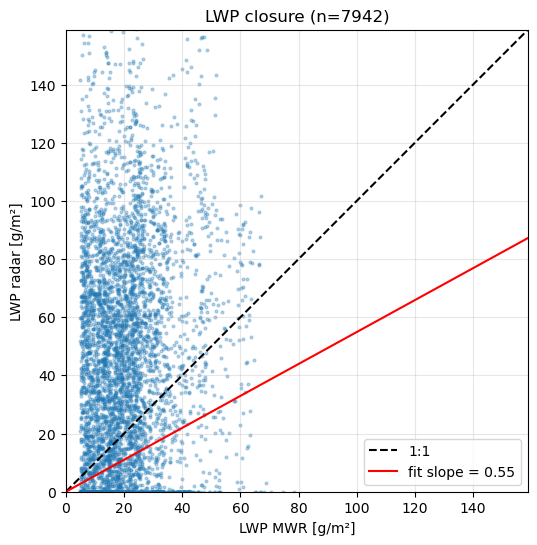

Slope through origin: 0.55   (want ~1.0)
Correlation:          -0.00   (want > 0.7)
Bias:  radar - MWR = -4.8 g/m²


In [ ]:
# %% LWP closure test
# Integrate guarded LWC to LWP in g/m² (note: NO /1000 — we want g/m², not kg/m²)
dz = float(dwr_2km_smoothed["range"].diff("range").mean())   # ~22.4 m
lwp_radar = (lwc_clean.where(ds_retrieval["cloud_mask"]).fillna(0) * dz).sum(dim="range")
lwp_radar = lwp_radar.where(ds_retrieval["cloud_mask"].any(dim="range"))   # NaN if no cloud
lwp_radar.attrs["units"] = "g m-2"


# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
x = ds_retrieval["LWP"].values
y = lwp_radar.values
good = np.isfinite(x) & np.isfinite(y) & (x > 5)   # ignore near-zero MWR
ax.scatter(x[good], y[good], s=4, alpha=0.3)
lim = max(np.nanpercentile(x[good], 99), np.nanpercentile(y[good], 99))
ax.plot([0, lim], [0, lim], "k--", label="1:1")
slope = np.nansum(x[good] * y[good]) / np.nansum(x[good] ** 2)
ax.plot([0, lim], [0, slope * lim], "r-", label=f"fit slope = {slope:.2f}")
ax.set_xlabel("LWP MWR [g/m²]"); ax.set_ylabel("LWP radar [g/m²]")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"LWP closure (n={good.sum()})")
plt.show()

corr = np.corrcoef(x[good], y[good])[0, 1]
print(f"Slope through origin: {slope:.2f}   (want ~1.0)")
print(f"Correlation:          {corr:.2f}   (want > 0.7)")
print(f"Bias:  radar - MWR = {np.nanmean(y[good] - x[good]):+.1f} g/m²")


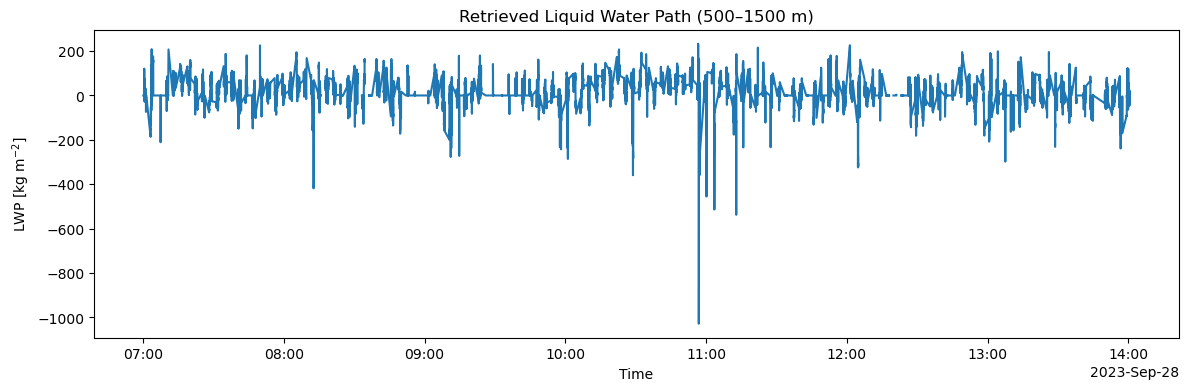

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp_radar.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path (500–1500 m)")
ax.set_ylabel("LWP [kg m$^{-2}$]")
ax.set_xlabel("Time")

plt.show()

Window only 500m to 1500 m

In [ ]:
# Height mask (True only between 500 and 1500 m)
height_mask = (
    (ds_retrieval["range"] >= 500) &
    (ds_retrieval["range"] <= 1500)
)

# Combine with the existing cloud mask
cloud_mask_height = ds_retrieval["cloud_mask"] & height_mask



In [ ]:
lwc_guarded_500, n_windows = retrieve_lwc_zhu_guarded(
    dwr=ds_retrieval["DWR"],
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=cloud_mask_height,
    N_default=9,
)

In [ ]:
# Mean gate spacing (m)
dz = float(
    ds_retrieval["range"]
    .sel(range=slice(500, 1500))
    .diff("range")
    .mean()
)

print(f"Gate spacing = {dz:.1f} m")

# Integrate LWC over height
lwp_guarded_500 = (lwc_guarded_500 * dz).sum(dim="range") / 1000

lwp_guarded_500.name = "LWP"
lwp_guarded_500.attrs["units"] = "kg m^-2"

Gate spacing = 27.0 m


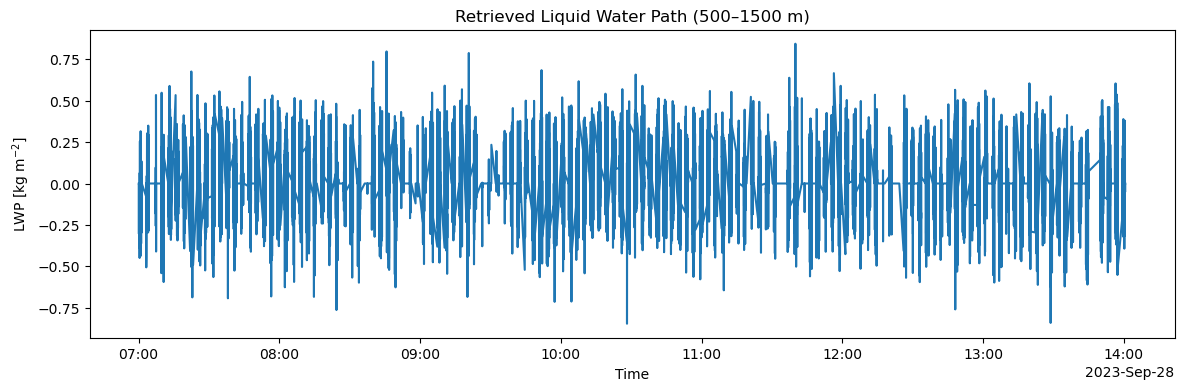

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp_guarded_500.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path (500–1500 m)")
ax.set_ylabel("LWP [kg m$^{-2}$]")
ax.set_xlabel("Time")

plt.show()

In [ ]:
lwc_2.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)